<a href="https://colab.research.google.com/github/Nat-magui/TelecomX_Churn_Prediction/blob/main/TelecomX_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Telecom X – Predicción de Cancelación de Clientes (Churn)


## 1️⃣ Introducción


### 📌 Contexto del problema

En el sector de telecomunicaciones, uno de los principales desafíos para las empresas es la **cancelación de clientes**, también conocida como **churn**.
El churn ocurre cuando un cliente decide **dejar de utilizar los servicios de la empresa**, lo que implica una pérdida directa de ingresos y un aumento en los costos asociados a la adquisición de nuevos clientes.

Para empresas como **Telecom X**, comprender y anticipar este comportamiento es fundamental para mantener la estabilidad del negocio y mejorar la relación con sus clientes.

En la **primera etapa del proyecto**, se realizó un proceso de **análisis exploratorio de datos (EDA)**, donde se identificaron distintos factores asociados con la cancelación de clientes, como el tipo de contrato, el tiempo de permanencia y el gasto mensual.

### 🎯 Objetivo del proyecto

El objetivo de esta segunda etapa es desarrollar **modelos de Machine Learning** capaces de **predecir la probabilidad de cancelación de un cliente** a partir de sus características y comportamiento.

Para ello se utilizará el dataset previamente preparado y tratado en la **Parte 1 del desafío**, aplicando técnicas de:

* preparación de datos para modelado,
* entrenamiento de modelos predictivos,
* evaluación del rendimiento de los modelos,
* interpretación de las variables más influyentes en la cancelación.

### 🚀 Importancia del análisis predictivo

La utilización de **modelos predictivos de churn** permite a las empresas anticipar qué clientes tienen mayor riesgo de abandonar el servicio.

Con esta información, Telecom X podría:

* implementar **estrategias de retención temprana**,
* ofrecer **beneficios personalizados** a clientes con alto riesgo,
* mejorar la **experiencia del cliente** en las etapas iniciales del servicio,
* optimizar sus **estrategias comerciales y de fidelización**.

De esta forma, el uso de **ciencia de datos y machine learning** se convierte en una herramienta clave para **reducir la cancelación de clientes y mejorar la sostenibilidad del negocio**.


## 2️⃣ Importación de librerías


En esta sección se importan las bibliotecas necesarias para la preparación de los datos, el entrenamiento de los modelos predictivos y la evaluación de su rendimiento.

Las librerías utilizadas permiten:

* manipular y analizar datos tabulares,
* generar visualizaciones para apoyar el análisis,
* dividir los datos en conjuntos de entrenamiento y prueba,
* normalizar variables numéricas cuando sea necesario,
* entrenar modelos de clasificación,
* evaluar el desempeño de los modelos mediante métricas.

En este proyecto se utilizarán principalmente bibliotecas del ecosistema de **Python para Ciencia de Datos y Machine Learning**, como **Pandas**, **NumPy**, **Matplotlib**, **Seaborn** y **Scikit-learn**.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

### 📌 Configuración opcional de visualización

Para que los gráficos se vean más claros y prolijos dentro del notebook, se puede agregar una configuración básica de estilo:


In [4]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 3️⃣ Carga de datos

### 📂 Dataset tratado


En esta etapa se carga el dataset que fue **preparado y limpiado en la Parte 1 del challenge**.
Este archivo contiene los datos ya transformados, normalizados y listos para ser utilizados en el entrenamiento de modelos de **Machine Learning**.

El dataset incluye información sobre características demográficas de los clientes, servicios contratados, condiciones del contrato y comportamiento de pago, junto con la variable objetivo **Churn**, que indica si el cliente canceló o no el servicio.


In [5]:
df = pd.read_csv("datos_tratados.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias,Cantidad_Servicios
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667,3
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667,1
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,4
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667,2


La función `head()` permite visualizar las primeras filas del dataset para confirmar que los datos se cargaron correctamente.


### 🔎 Verificación de la estructura del dataset


Después de cargar los datos, es importante verificar la **estructura general del dataset**, incluyendo la cantidad de filas, columnas y tipos de datos.


In [6]:
df.shape

(7043, 23)

Esto muestra las **dimensiones del dataset**:

* número de registros (clientes)
* número de variables

Luego se revisan los tipos de datos de cada columna:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   Churn               7043 non-null   int64  
 2   gender              7043 non-null   object 
 3   SeniorCitizen       7043 non-null   int64  
 4   Partner             7043 non-null   int64  
 5   Dependents          7043 non-null   int64  
 6   tenure              7043 non-null   int64  
 7   PhoneService        7043 non-null   int64  
 8   MultipleLines       7043 non-null   object 
 9   InternetService     7043 non-null   object 
 10  OnlineSecurity      7043 non-null   object 
 11  OnlineBackup        7043 non-null   object 
 12  DeviceProtection    7043 non-null   object 
 13  TechSupport         7043 non-null   object 
 14  StreamingTV         7043 non-null   object 
 15  StreamingMovies     7043 non-null   object 
 16  Contra

Esta función permite observar:

* tipos de variables (numéricas o categóricas)
* presencia de valores nulos
* estructura general del dataset


### 📊 Vista general del dataset


Para tener una idea rápida de cómo se distribuyen los datos, también se pueden observar algunas estadísticas descriptivas de las variables numéricas:


In [8]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Cuentas_Diarias,Cantidad_Servicios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158723,2.037910
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003002,1.847682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.183333,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.345000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.995000,3.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333,6.000000


Esto permite identificar valores promedio, rangos y posibles anomalías en los datos antes de comenzar con el proceso de **preparación para el modelado**.


## 4️⃣ Preparación de los datos


Antes de entrenar los modelos de **Machine Learning**, es necesario realizar algunos pasos adicionales de preparación de los datos.
Estos pasos permiten asegurar que todas las variables tengan el formato adecuado para ser utilizadas por los algoritmos de clasificación.

En esta etapa se realizarán las siguientes tareas:

* eliminación de columnas irrelevantes
* transformación de variables categóricas a variables numéricas
* verificación de la distribución de la variable objetivo **Churn**

### Eliminación de columnas irrelevantes


Algunas variables del dataset no aportan información útil para el modelo.
En particular, la columna **`customerID`** es simplemente un identificador único de cada cliente y no tiene valor predictivo.

Por este motivo, se elimina del dataset antes de continuar con el análisis.

In [9]:
df = df.drop(columns=["customerID"])

### Transformación de variables categóricas (Encoding)


Los modelos de **Machine Learning** trabajan con datos numéricos, por lo que las variables categóricas deben transformarse a un formato numérico.

Para ello se utiliza la técnica **One-Hot Encoding**, que crea nuevas columnas binarias para representar cada categoría.

La función `pd.get_dummies()` permite realizar esta transformación de forma automática.

In [10]:
df = pd.get_dummies(df, drop_first=True)

El parámetro `drop_first=True` evita la **multicolinealidad**, eliminando una de las categorías de cada variable.

Después de esta transformación, variables como:

* `Contract`
* `InternetService`
* `PaymentMethod`
* `MultipleLines`
* `OnlineSecurity`
* `StreamingTV`

se convierten en columnas binarias (0 o 1).

### Verificación de la distribución de churn


Antes de entrenar los modelos, es importante analizar la **distribución de la variable objetivo**.

Esto permite identificar si existe un **desbalance de clases**, lo cual puede afectar el rendimiento de los modelos predictivos.

In [11]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


También se puede visualizar la distribución mediante un gráfico:

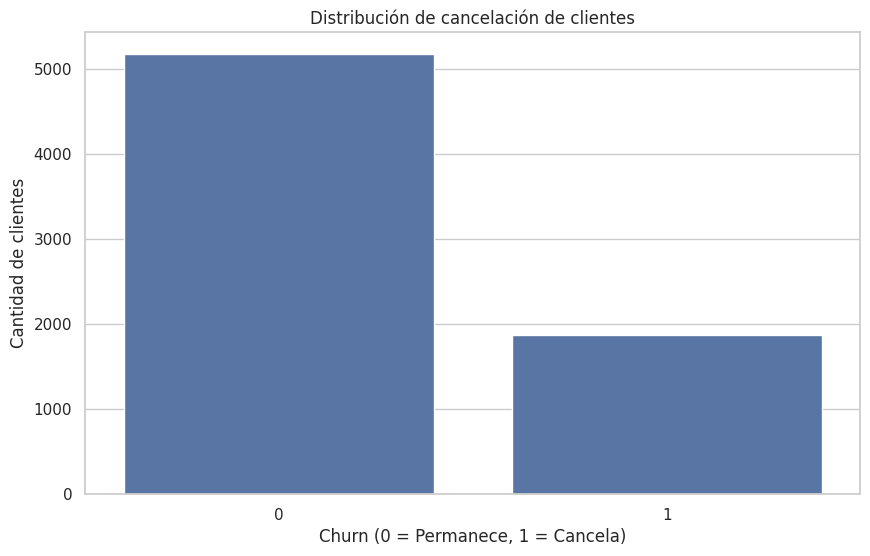

In [12]:
sns.countplot(x="Churn", data=df)
plt.title("Distribución de cancelación de clientes")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Cantidad de clientes")
plt.show()

En este dataset se observa aproximadamente la siguiente distribución:
En este dataset se observa aproximadamente la siguiente distribución:

```
Clientes que permanecen (0) → ~73%
Clientes que cancelan (1) → ~27%
```

Esto indica un **ligero desbalance de clases**, que es común en problemas de churn, pero que sigue siendo manejable para los modelos que se utilizarán en este proyecto.

## 5️⃣ Análisis de correlación


El análisis de correlación permite identificar **qué variables del dataset están más relacionadas con la cancelación de clientes (Churn)**.

Las correlaciones ayudan a:

* detectar patrones en los datos
* identificar variables potencialmente importantes para los modelos predictivos
* comprender mejor qué factores influyen en la cancelación de clientes

Los valores de correlación pueden variar entre:

* **1** → correlación positiva fuerte
* **0** → no hay relación
* **-1** → correlación negativa fuerte

Una correlación **positiva** indica que a mayor valor de la variable, mayor probabilidad de churn.
Una correlación **negativa** indica que a mayor valor de la variable, menor probabilidad de churn.

### Matriz de correlación


Primero se visualiza la matriz completa de correlaciones entre todas las variables del dataset.


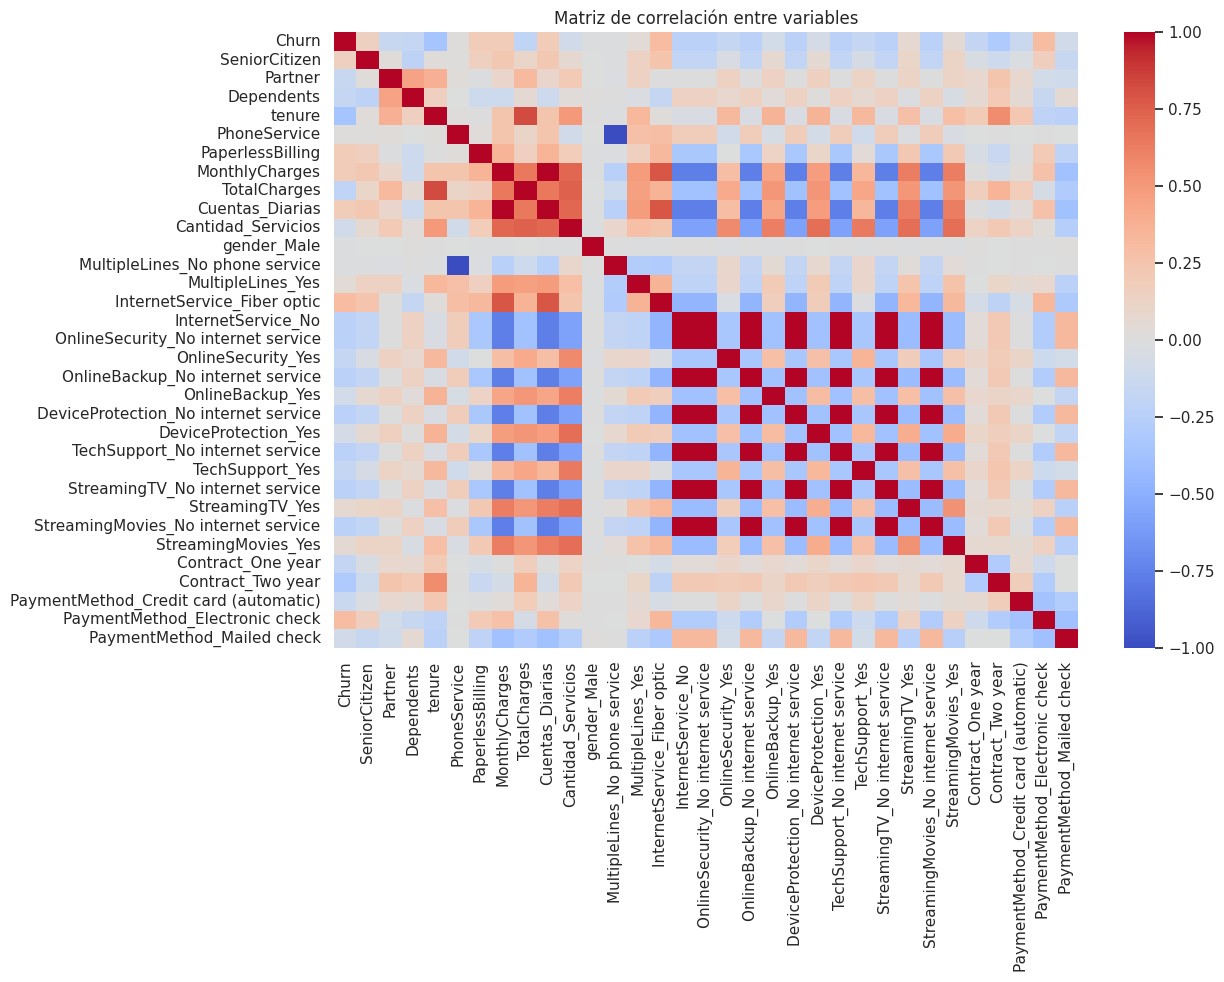

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación entre variables")
plt.show()

Este gráfico permite observar visualmente qué variables presentan mayor relación entre sí.


#### Interpretación del heatmap de correlación


##### 🔹 Relaciones más claras con **Churn**

En la primera fila/columna (Churn) se pueden observar algunas relaciones interesantes:

**Correlaciones positivas (más churn)**
Variables que aumentan la probabilidad de cancelación:

* **MonthlyCharges** → clientes con cargos mensuales más altos tienden a cancelar más.
* **InternetService_Fiber optic** → clientes con fibra óptica muestran mayor churn.
* **PaymentMethod_Electronic check** → este método de pago aparece asociado a más cancelaciones.
* **PaperlessBilling** → ligera relación con mayor churn.

Estas correlaciones no son muy fuertes, pero son **las más visibles**.

**Correlaciones negativas (menos churn)**
Variables asociadas con **mayor permanencia del cliente**:

* **tenure** → clientes con mayor antigüedad cancelan menos.
* **TotalCharges** → clientes que han pagado más en total suelen permanecer más tiempo.
* **Contract_One year**
* **Contract_Two year**

Esto confirma algo muy típico en churn:

➡ **los contratos largos reducen mucho la cancelación.**

##### 🔹 Correlaciones fuertes entre variables

También se observan algunas correlaciones fuertes entre variables del dataset:

**tenure ↔ TotalCharges**

Esto es lógico porque:

* cuanto más tiempo permanece un cliente,
* mayor será su gasto acumulado.


**MonthlyCharges ↔ Cuentas_Diarias**

Correlación casi perfecta porque:

* `Cuentas_Diarias` se calculó directamente desde `MonthlyCharges`.

**Servicios de internet**

Las variables:

* OnlineSecurity
* OnlineBackup
* DeviceProtection
* TechSupport
* StreamingTV
* StreamingMovies

aparecen muy correlacionadas entre sí porque representan **servicios adicionales de internet**.

# Conclusión del análisis de correlación

El análisis muestra que los factores más relacionados con la cancelación de clientes son:

* **antigüedad del cliente (tenure)**
* **tipo de contrato**
* **costo mensual del servicio**
* **tipo de servicio de internet**
* **método de pago**

En particular, los clientes con:

* **contratos mensuales**
* **mayor costo mensual**
* **menor antigüedad**

presentan una mayor probabilidad de cancelar el servicio.

Estos resultados coinciden con los patrones identificados previamente en el análisis exploratorio y ayudan a entender qué variables pueden ser más relevantes para los **modelos predictivos de churn**.


### Variables más relacionadas con churn


Para identificar de forma más clara qué variables están más asociadas con la cancelación, se ordenan las correlaciones respecto a la variable **Churn**.


In [15]:
corr = df.corr()["Churn"].sort_values(ascending=False)
corr.head(10)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
Cuentas_Diarias,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102


Esto muestra las **variables con mayor correlación positiva con churn**, es decir, aquellas asociadas a mayor probabilidad de cancelación.

También puede ser útil observar las variables con **correlación negativa**, que suelen estar asociadas con mayor permanencia del cliente.

In [16]:
corr.tail(10)

,Churn
TotalCharges,-0.198324
InternetService_No,-0.227890
StreamingTV_No internet service,-0.227890
OnlineSecurity_No internet service,-0.227890
OnlineBackup_No internet service,-0.227890
DeviceProtection_No internet service,-0.227890
StreamingMovies_No internet service,-0.227890
TechSupport_No internet service,-0.227890
Contract_Two year,-0.302253
tenure,-0.352229


### Interpretación del análisis


A partir de este análisis, es posible identificar algunos patrones relevantes.

Por ejemplo, variables como:

* **tenure (antigüedad del cliente)**
* **tipo de contrato**
* **costo mensual del servicio**

suelen presentar una relación significativa con el churn.

En particular, una **correlación negativa de tenure** indicaría que los clientes con mayor tiempo en la empresa tienden a cancelar menos, mientras que ciertas características del servicio o del contrato podrían estar asociadas con una mayor probabilidad de cancelación.

Estos resultados ayudan a comprender mejor el comportamiento de los clientes y sirven como base para interpretar los **modelos predictivos** que se desarrollarán en las siguientes secciones.


## 6️⃣ Análisis dirigido


En esta sección se analizan relaciones específicas entre algunas variables importantes del dataset y la cancelación de clientes (**Churn**).

El objetivo es observar cómo se comportan ciertas variables entre los clientes que **permanecen** en la empresa y aquellos que **cancelan el servicio**.

Para este análisis se utilizan **boxplots**, que permiten comparar la distribución de valores entre ambos grupos.

### Antigüedad del cliente vs churn


La variable **tenure** representa la cantidad de meses que un cliente lleva utilizando el servicio.

Analizar esta variable permite observar si la cancelación ocurre más frecuentemente en clientes nuevos o en clientes con mayor antigüedad.

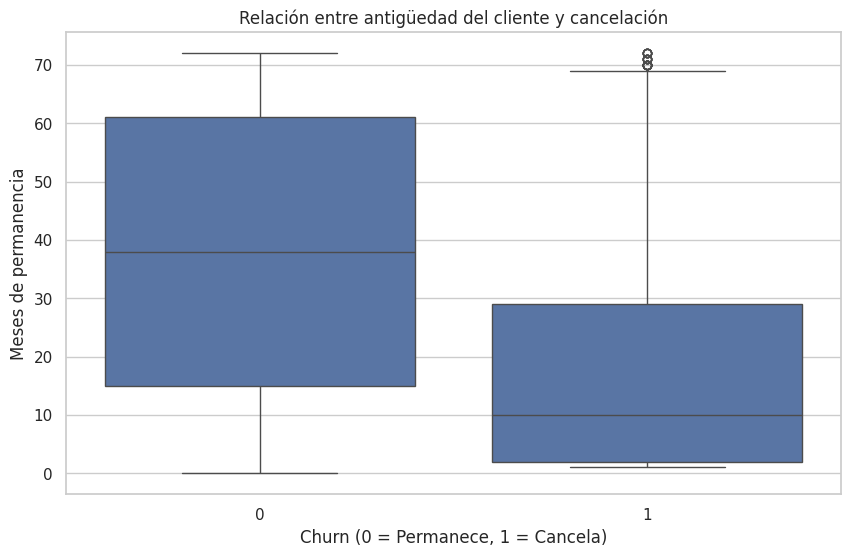

In [17]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Relación entre antigüedad del cliente y cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Meses de permanencia")
plt.show()

#### Interpretación


El gráfico muestra una diferencia clara entre ambos grupos de clientes.

Los clientes que **cancelan el servicio (Churn = 1)** presentan una **antigüedad considerablemente menor**, concentrándose principalmente en los primeros meses de permanencia. En cambio, los clientes que **permanecen en la empresa (Churn = 0)** presentan una distribución mucho más amplia de antigüedad, con muchos clientes que superan los 40 meses de permanencia.

Este resultado sugiere que **la cancelación ocurre con mayor frecuencia en etapas tempranas de la relación con el cliente**, lo que indica que los primeros meses del servicio son críticos para la retención.

### Gasto mensual vs churn


La variable **MonthlyCharges** representa el cargo mensual del servicio contratado.

Analizar esta variable permite identificar si los clientes con mayores costos presentan mayor probabilidad de cancelar el servicio.

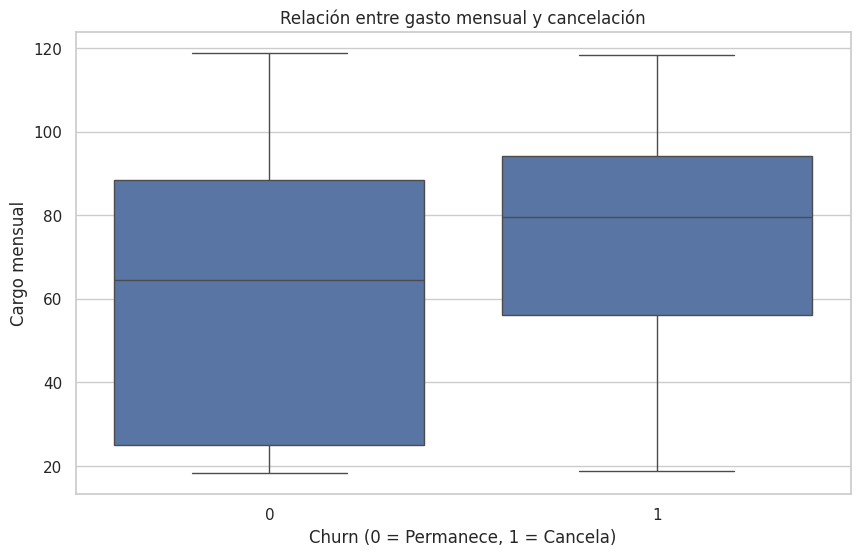

In [18]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Relación entre gasto mensual y cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Cargo mensual")
plt.show()

#### Interpretación


El gráfico muestra que los clientes que cancelan el servicio tienden a presentar **cargos mensuales más altos en promedio** que los clientes que permanecen.

La mediana del gasto mensual es mayor en el grupo que cancela, lo que sugiere que **los planes con mayor costo podrían estar asociados a una mayor probabilidad de cancelación**. Esto podría estar relacionado con la percepción de valor del servicio o con la existencia de alternativas más competitivas en el mercado.


### Gasto total vs churn


La variable **TotalCharges** representa el gasto acumulado del cliente a lo largo de su permanencia en la empresa.


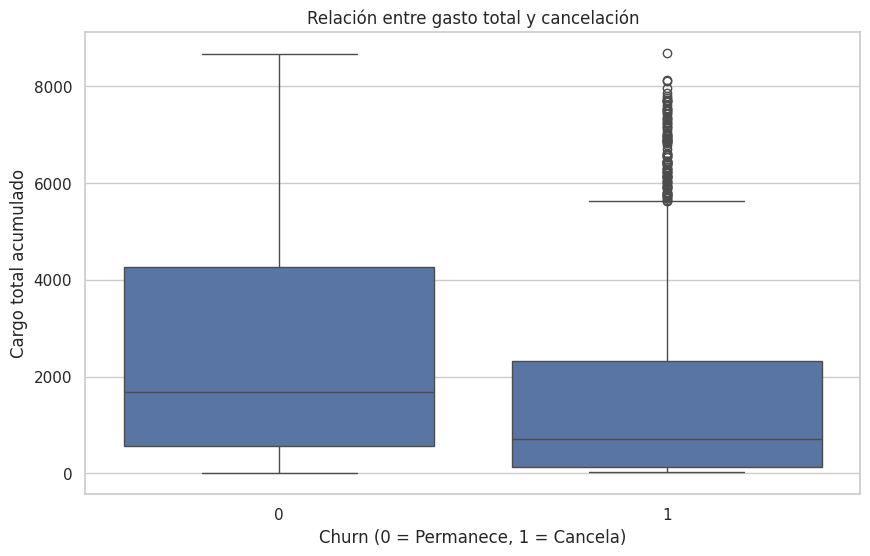

In [19]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Relación entre gasto total y cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Cargo total acumulado")
plt.show()

#### Interpretación


El gráfico muestra que los clientes que permanecen en la empresa presentan **valores significativamente más altos de gasto total acumulado**, mientras que los clientes que cancelan suelen tener gastos totales mucho menores.

Esto se explica porque el gasto total está directamente relacionado con la antigüedad del cliente: los clientes que llevan más tiempo en la empresa acumulan mayores cargos totales. En cambio, muchos clientes que cancelan lo hacen en etapas tempranas del servicio, lo que se refleja en valores más bajos de gasto total.


### Conclusión del análisis dirigido


Los gráficos analizados muestran patrones claros en el comportamiento de cancelación de clientes. En particular, se observa que los clientes con **menor antigüedad y mayores cargos mensuales presentan una mayor probabilidad de cancelar el servicio**, mientras que los clientes con mayor permanencia y mayor gasto acumulado tienden a mantenerse en la empresa.

Estos resultados refuerzan la importancia de implementar **estrategias de retención temprana**, especialmente durante los primeros meses de relación con el cliente.



## 7️⃣ Separación de datos (Train/Test)

Antes de entrenar los modelos predictivos, es necesario dividir el dataset en dos conjuntos:

* **conjunto de entrenamiento**, que se utiliza para ajustar el modelo
* **conjunto de prueba**, que se utiliza para evaluar su rendimiento con datos no vistos previamente

Esta división es fundamental para comprobar la capacidad de generalización del modelo y evitar conclusiones basadas únicamente en los datos usados durante el entrenamiento.

En este proyecto se utilizará una división de:

* **80% de los datos para entrenamiento**
* **20% de los datos para prueba**

Primero se separan las variables predictoras (**X**) de la variable objetivo (**y**):

In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

Luego se realiza la división del dataset:


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

El parámetro `random_state=42` permite que la partición de los datos sea **reproducible**, es decir, que se obtenga siempre la misma división al volver a ejecutar el notebook.


### Verificación de dimensiones


Para confirmar que la separación se realizó correctamente, se pueden revisar las dimensiones de cada conjunto:


In [22]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (5634, 32)
X_test: (1409, 32)
y_train: (5634,)
y_test: (1409,)


Esto indica que:

* **5634 registros** fueron utilizados para entrenar los modelos.
* **1409 registros** fueron reservados para evaluar el rendimiento del modelo.
* El dataset contiene **32 variables predictoras** después del proceso de preparación y encoding.

La proporción se mantiene cercana al **80% para entrenamiento y 20% para prueba**, lo cual es una práctica común en proyectos de machine learning para garantizar una evaluación confiable del modelo.


### Interpretación


Esta separación permite entrenar los modelos con una parte del dataset y luego evaluar su rendimiento con datos nuevos, simulando una situación más cercana a un escenario real.

A partir de esta división, los siguientes pasos del proyecto consistirán en:

* normalizar los datos cuando sea necesario
* entrenar distintos modelos de clasificación
* comparar sus resultados mediante métricas de evaluación


## 8️⃣ Normalización de datos


En algunos algoritmos de machine learning es necesario **escalar las variables numéricas** para que todas tengan una magnitud comparable.

Esto es especialmente importante en modelos que utilizan **distancias o optimización de coeficientes**, como:

* Regresión Logística
* K-Nearest Neighbors
* Support Vector Machines

En estos casos, variables con valores más grandes pueden dominar el cálculo del modelo si no se realiza un proceso de normalización o estandarización.

Para este proyecto se utiliza **StandardScaler**, que transforma las variables de modo que tengan:

* media igual a **0**
* desviación estándar igual a **1**

Esto permite que todas las variables contribuyan de forma equilibrada al modelo.


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Es importante ajustar el escalador **solo con los datos de entrenamiento** (`fit_transform`) y luego aplicarlo a los datos de prueba (`transform`). Esto evita que el modelo incorpore información del conjunto de prueba durante el entrenamiento.

Cabe destacar que **modelos basados en árboles**, como Random Forest o Decision Trees, **no requieren normalización**, ya que realizan divisiones basadas en umbrales y no en distancias entre variables.


## 9️⃣ Creación de modelos predictivos


En esta etapa se entrenan modelos de **Machine Learning** con el objetivo de predecir si un cliente tiene probabilidad de cancelar el servicio.

Para este proyecto se utilizarán **dos modelos de clasificación**:

* **Regresión Logística**, un modelo lineal ampliamente utilizado en problemas de clasificación binaria.
* **Random Forest**, un modelo basado en árboles de decisión que suele ofrecer buen rendimiento en problemas con relaciones no lineales.

La comparación entre ambos permitirá evaluar cuál se adapta mejor al problema de predicción de churn en Telecom X.


### Modelo 1: Regresión Logística


La **Regresión Logística** es uno de los modelos más utilizados para problemas de clasificación binaria, ya que permite estimar la probabilidad de que un registro pertenezca a una determinada clase.

En este caso, el modelo se utilizará para estimar la probabilidad de que un cliente:

* **permanezca en la empresa (0)**
* **cancele el servicio (1)**

Dado que este modelo es sensible a la escala de las variables, se entrenará utilizando los datos previamente **normalizados**.


In [24]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

### Interpretación


Con este paso, el modelo aprende patrones a partir de los datos de entrenamiento y luego genera predicciones sobre el conjunto de prueba.

Las predicciones almacenadas en `y_pred_log` se utilizarán posteriormente para evaluar el rendimiento del modelo mediante métricas como:

* accuracy
* precision
* recall
* f1-score
* matriz de confusión

La Regresión Logística también tiene la ventaja de ser un modelo relativamente interpretable, ya que permite analizar cómo influyen las variables en la probabilidad de churn.


### Modelo 2: Random Forest


El segundo modelo utilizado es **Random Forest**, un algoritmo de aprendizaje automático basado en un conjunto de **árboles de decisión**.

Este modelo pertenece a la familia de métodos **ensemble**, lo que significa que combina múltiples modelos simples (árboles) para producir una predicción más robusta y precisa.

Random Forest funciona creando varios árboles de decisión durante el entrenamiento y luego combina sus resultados mediante un sistema de votación para generar la predicción final.

Una ventaja importante de este modelo es que:

* maneja bien relaciones **no lineales**
* es **menos sensible al overfitting** que un árbol de decisión individual
* permite analizar la **importancia de las variables**

A diferencia de la Regresión Logística, los modelos basados en árboles **no requieren normalización de los datos**, por lo que se entrenan directamente con las variables originales.


In [25]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


### Interpretación


En este caso, el modelo Random Forest aprende patrones a partir del conjunto de entrenamiento y luego genera predicciones sobre el conjunto de prueba.

Las predicciones se almacenan en la variable `y_pred_rf`, que posteriormente será utilizada para evaluar el rendimiento del modelo mediante métricas de clasificación.

Comparar los resultados obtenidos con **Regresión Logística** y **Random Forest** permitirá determinar cuál de los modelos ofrece un mejor desempeño para la predicción de cancelación de clientes.


## 🔟 Evaluación de modelos


Una vez entrenados los modelos predictivos, es necesario evaluar su rendimiento utilizando el conjunto de **datos de prueba**.
Esto permite analizar qué tan bien el modelo es capaz de **generalizar a datos que no fueron utilizados durante el entrenamiento**.

Para esta evaluación se utilizarán varias métricas de clasificación, entre ellas:

* **Accuracy**: proporción de predicciones correctas sobre el total de observaciones.
* **Precision**: proporción de predicciones positivas correctas respecto al total de predicciones positivas.
* **Recall**: proporción de casos positivos correctamente identificados.
* **F1-score**: media armónica entre precisión y recall, útil cuando existe cierto desbalance entre clases.

Estas métricas se obtienen mediante la función `classification_report`, que resume el rendimiento del modelo para cada clase.


In [26]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.67      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



### Matriz de confusión


Además del reporte de métricas, es útil analizar la **matriz de confusión**, que permite observar cómo se distribuyen las predicciones correctas e incorrectas del modelo.

La matriz de confusión muestra cuatro posibles resultados:

* **Verdaderos negativos (TN)**: clientes que permanecen y el modelo predice correctamente que permanecerán.
* **Verdaderos positivos (TP)**: clientes que cancelan y el modelo predice correctamente la cancelación.
* **Falsos positivos (FP)**: clientes que permanecen pero el modelo predice que cancelarán.
* **Falsos negativos (FN)**: clientes que cancelan pero el modelo predice que permanecerán.

Esta matriz permite entender **qué tipo de errores está cometiendo el modelo**.


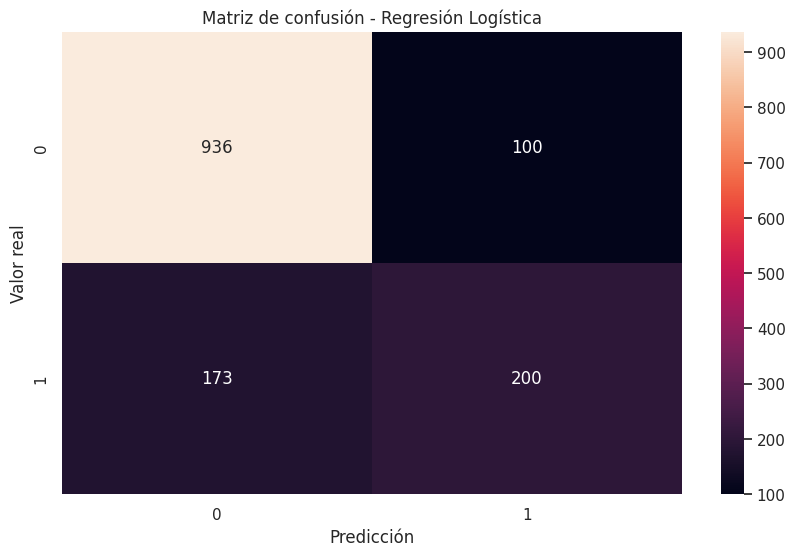

In [27]:
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

También se puede visualizar la matriz de confusión para el modelo **Random Forest**:


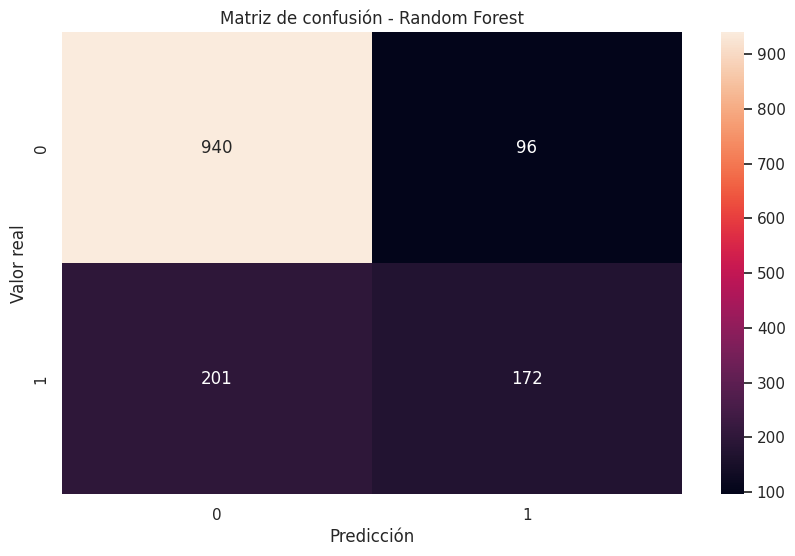

In [28]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


### Interpretación


El análisis de las métricas permite comparar el desempeño de ambos modelos.
En este caso, la **Regresión Logística obtuvo una accuracy aproximada de 0.81**, mientras que **Random Forest alcanzó cerca de 0.79**.

Aunque ambos modelos presentan resultados similares, la **Regresión Logística muestra un rendimiento ligeramente superior en este conjunto de datos**.


### Interpretación de resultados


Analizando las métricas de clasificación se observa que:

**Regresión Logística**

* Precision (churn): **0.67**
* Recall (churn): **0.54**
* F1-score: **0.59**

**Random Forest**

* Precision (churn): **0.64**
* Recall (churn): **0.46**
* F1-score: **0.54**

En problemas de **predicción de churn**, el **recall de la clase de cancelación** es especialmente importante, ya que indica la capacidad del modelo para detectar clientes que tienen riesgo de abandonar el servicio.

En este caso, la **Regresión Logística logra identificar más clientes que cancelan**, mientras que Random Forest presenta mayor dificultad para detectar esta clase.

Por esta razón, la **Regresión Logística resulta ligeramente más adecuada para este problema**, ya que permite identificar una mayor proporción de clientes con riesgo de churn.

## 1️⃣1️⃣ Importancia de variables


Una vez evaluados los modelos, es importante identificar **qué variables influyen más en la predicción de cancelación de clientes**.

Este análisis permite pasar del rendimiento técnico del modelo a una interpretación más orientada al negocio, ya que ayuda a responder preguntas como:

* ¿qué factores están más relacionados con el churn?
* ¿qué perfil de cliente presenta mayor riesgo de cancelación?
* ¿sobre qué variables podría actuar la empresa para mejorar la retención?

En el caso del modelo **Random Forest**, esta interpretación puede realizarse mediante la **importancia de variables** (`feature_importances_`), que indica cuánto aporta cada variable a la capacidad predictiva del modelo.


In [29]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)


,0
TotalCharges,0.160035
tenure,0.151859
MonthlyCharges,0.125168
Cuentas_Diarias,0.123948
Contract_Two year,0.038229
PaymentMethod_Electronic check,0.037771
Cantidad_Servicios,0.034508
InternetService_Fiber optic,0.031489
gender_Male,0.023220
PaperlessBilling,0.022617


Este resultado permite observar cuáles son las variables más relevantes para la predicción del churn.


### Visualización de las variables más importantes


Para facilitar la interpretación, también es útil representar gráficamente las variables más relevantes.


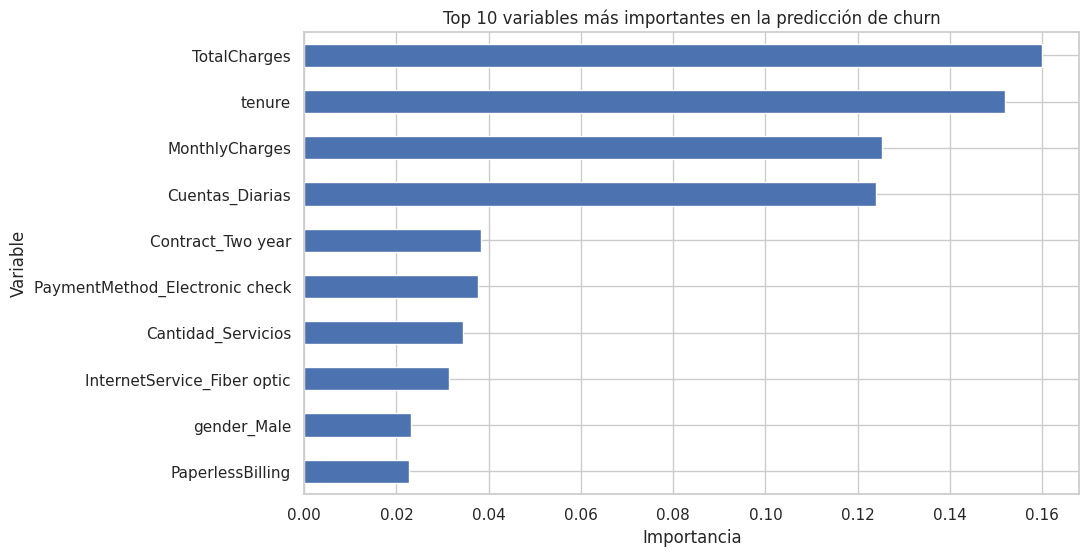

In [30]:
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 variables más importantes en la predicción de churn")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


### Interpretación


El análisis de importancia de variables del modelo **Random Forest** muestra que las variables con mayor influencia en la predicción de cancelación son principalmente aquellas relacionadas con **la permanencia del cliente y el nivel de gasto en los servicios**.

Las variables más relevantes identificadas por el modelo fueron:

* **TotalCharges**
* **tenure**
* **MonthlyCharges**
* **Cuentas_Diarias**

Estas variables sugieren que el **comportamiento de pago y la antigüedad del cliente** son factores clave para explicar la cancelación de servicios.

En particular:

* **TotalCharges y tenure** indican que los clientes con mayor tiempo en la empresa y mayor gasto acumulado tienden a presentar un comportamiento diferente respecto a la cancelación.
* **MonthlyCharges y Cuentas_Diarias** reflejan el impacto del costo del servicio en la probabilidad de churn.

También aparecen variables relacionadas con el **tipo de contrato y forma de pago**, como:

* **Contract_Two year**
* **PaymentMethod_Electronic check**

Esto sugiere que **las condiciones contractuales y los métodos de pago pueden influir en la decisión de cancelar el servicio**.

Finalmente, variables asociadas a los servicios contratados y características del cliente, como **Cantidad_Servicios** o **InternetService_Fiber optic**, también aportan información relevante para la predicción.


### Valor del análisis de importancia


El análisis de importancia de variables no solo ayuda a interpretar el modelo, sino que también permite traducir los resultados a decisiones de negocio.

Por ejemplo, si el modelo identifica que variables como la **antigüedad del cliente**, el **tipo de contrato** o el **método de pago** tienen un peso importante en la predicción, Telecom X podría diseñar estrategias específicas para actuar sobre esos factores y reducir la probabilidad de cancelación.


### Conclusión del análisis de variables


En conjunto, los resultados indican que **la antigüedad del cliente, el nivel de gasto y las características del contrato** son factores determinantes en la predicción de cancelación.

Estos hallazgos coinciden con los patrones observados previamente en el análisis exploratorio y en los gráficos del análisis dirigido, lo que refuerza la consistencia del modelo y del análisis realizado.


## 1️⃣2️⃣ Comparación de modelos


Después de entrenar y evaluar los modelos de **Regresión Logística** y **Random Forest**, es posible comparar su rendimiento utilizando las métricas obtenidas en el conjunto de prueba.

En términos de **accuracy**, ambos modelos presentan resultados similares:

* **Regresión Logística:** ~0.81
* **Random Forest:** ~0.79

Esto indica que ambos modelos logran clasificar correctamente una proporción similar de clientes en general.

Sin embargo, en problemas de **predicción de churn**, la métrica más relevante suele ser el **recall de la clase de cancelación**, ya que el objetivo principal es identificar la mayor cantidad posible de clientes que tienen riesgo de abandonar el servicio.

Analizando esta métrica se observa que:

* **Regresión Logística**

  * Recall (churn): **0.54**

* **Random Forest**

  * Recall (churn): **0.46**

Esto significa que la **Regresión Logística logra identificar una mayor proporción de clientes que cancelan el servicio**, mientras que Random Forest detecta menos casos de churn.

Por otro lado, Random Forest muestra un desempeño ligeramente mejor al clasificar a los clientes que **permanecen en la empresa**, lo que se observa en su buen rendimiento para la clase 0.


### Modelo más adecuado para el problema


Considerando que el objetivo del proyecto es **anticipar la cancelación de clientes**, el modelo de **Regresión Logística resulta más adecuado**, ya que presenta un **mayor recall en la clase churn**, permitiendo detectar más clientes con riesgo de abandonar el servicio.

Esto puede ser especialmente útil para implementar **estrategias de retención dirigidas**, ya que permite identificar con mayor precisión a los clientes que podrían cancelar su contrato.


## 1️⃣3️⃣ Insights principales


A partir del análisis exploratorio, el modelado predictivo y la evaluación de importancia de variables, se identificaron varios patrones relevantes en el comportamiento de cancelación de clientes.

Uno de los factores más importantes es la **antigüedad del cliente (tenure)**. Se observa que los clientes con menor tiempo en la empresa presentan una mayor probabilidad de cancelar el servicio. Esto sugiere que los primeros meses de relación con el cliente son un período crítico para la retención.

Otro factor relevante es el **nivel de gasto mensual (MonthlyCharges)**. Los clientes con cargos mensuales más altos tienden a presentar una mayor tasa de cancelación, lo que podría indicar que el costo del servicio influye en la decisión de abandonar la empresa.

También se observa que el **gasto total acumulado (TotalCharges)** está fuertemente relacionado con la permanencia del cliente. Los clientes con mayor gasto acumulado suelen ser aquellos que llevan más tiempo utilizando los servicios y presentan una menor probabilidad de cancelar.

El **tipo de contrato** también muestra influencia en el comportamiento de churn. Los clientes con contratos de mayor duración, como los contratos de dos años, tienden a presentar menores tasas de cancelación en comparación con contratos más flexibles.

Además, variables relacionadas con los **servicios contratados y características del plan**, como la cantidad de servicios activos o el tipo de conexión a internet, también contribuyen a explicar el comportamiento de cancelación.

En conjunto, estos resultados muestran que la cancelación de clientes no depende de un único factor, sino de una combinación de variables relacionadas con la **antigüedad del cliente, el costo del servicio y las características del contrato**.



## 1️⃣4️⃣ Conclusiones


A partir del análisis exploratorio, el modelado predictivo y la evaluación de variables, fue posible identificar los principales factores asociados a la cancelación de clientes en Telecom X.

Los resultados muestran que variables como **la antigüedad del cliente (tenure)**, el **nivel de gasto mensual (MonthlyCharges)** y el **gasto total acumulado (TotalCharges)** tienen una influencia significativa en el comportamiento de churn. En particular, se observó que los clientes con menor tiempo en la empresa y con cargos mensuales más elevados presentan una mayor probabilidad de cancelar el servicio.

También se identificó que factores relacionados con las **condiciones contractuales y el método de pago** pueden influir en la decisión de los clientes de continuar o abandonar el servicio.

En cuanto al modelado predictivo, se compararon dos algoritmos de clasificación: **Regresión Logística** y **Random Forest**. Ambos modelos presentaron un rendimiento similar en términos de accuracy, aunque la **Regresión Logística mostró una mejor capacidad para identificar clientes que cancelan**, lo que la convierte en una alternativa más adecuada para este tipo de problema.

El desarrollo de un modelo predictivo de churn permite a la empresa anticiparse al comportamiento de cancelación y detectar clientes con mayor riesgo de abandono. Esto representa una herramienta valiosa para diseñar estrategias de retención más efectivas y mejorar la relación con los clientes.


## 1️⃣5️⃣ Recomendaciones estratégicas


A partir de los resultados obtenidos en el análisis y en los modelos predictivos, es posible proponer algunas estrategias que Telecom X podría implementar para reducir la cancelación de clientes.

Una de las principales recomendaciones es **incentivar contratos de mayor duración**. Los resultados sugieren que los clientes con contratos más largos tienden a presentar menores tasas de cancelación. Ofrecer descuentos, beneficios o servicios adicionales para quienes opten por contratos anuales o bianuales podría contribuir a mejorar la retención.

También es importante fortalecer los **programas de onboarding de nuevos clientes**. Dado que muchos casos de cancelación ocurren en los primeros meses de relación con la empresa, acompañar mejor a los clientes durante esta etapa inicial puede ayudar a mejorar su experiencia y reducir la probabilidad de abandono.

Otra posible estrategia consiste en **analizar la estructura de precios y cargos mensuales**. El análisis mostró que los clientes con cargos mensuales más elevados presentan una mayor tendencia a cancelar el servicio. Evaluar la percepción de valor del cliente o revisar la estructura de planes podría ayudar a reducir este efecto.

Además, el modelo predictivo desarrollado podría utilizarse como una **herramienta de monitoreo continuo**, permitiendo identificar clientes con alto riesgo de churn y aplicar acciones de retención específicas, como promociones personalizadas o mejoras en el servicio.

En conjunto, estas estrategias permitirían a Telecom X **anticiparse a la cancelación de clientes, mejorar la satisfacción y fortalecer la relación a largo plazo con sus usuarios**.


## 1️⃣6️⃣ Conclusión final





En este proyecto se aplicaron técnicas de **análisis de datos y machine learning** para estudiar y predecir la cancelación de clientes en Telecom X. A través del análisis exploratorio, la preparación de los datos y la construcción de modelos predictivos, fue posible identificar patrones relevantes en el comportamiento de los clientes.

Los resultados mostraron que variables como **la antigüedad del cliente, los cargos mensuales y las condiciones contractuales** tienen una influencia importante en la probabilidad de cancelación. Además, el modelo de **Regresión Logística** demostró ser una herramienta útil para identificar clientes con mayor riesgo de churn.

Este tipo de análisis permite a las empresas **anticiparse a la pérdida de clientes y diseñar estrategias de retención basadas en datos**, contribuyendo a mejorar la toma de decisiones y fortalecer la relación con los usuarios.

En conjunto, el uso de **ciencia de datos y modelos predictivos** representa una herramienta valiosa para transformar datos en conocimiento y generar impacto en la estrategia de negocio.
